# **Problem Description**

Dr. Adam Holley here at Tennessee Tech does research in accurately finding the lifetime of free neutrons (neutrons that are not part of a nucleus). Dr. Holley's research team currently have the most accurate measurement for the neutron lifetime in the world. An essential part of the research is being able to detect neutrons. Due to the fact the neutron has no electric charge, the neutron cannot be detected directly. Instead, neutrons are detected by having them collide and interact with some material to produce photons. The photons can then be detected which indicates the existence of a neutron.

A single neutron interaction will produce many photons in a short burst of time. In experiment, in the range of 1000-10000 neutrons will interact with the target material at a very fast rate producing many photons. The photons produced by different individual neutrons cannot be distinguished from one another, so all photon detections are put into the same data file. At the end of the experiment, the only data that exists are the detected photons. Therefore, data analysis of the photon data is required to reconstruct how many neutrons created a certain set of photon data. The accuracy of the experiment will depend upon how well this reconstruction algorithm performs.

A reconstruction algorithm already exists; however, machine learning can be used to achieve better accuracies.

# **Data Set**

The data set is 1D data with only one feature being the time of photon detection. It can be visualized via a histogram.

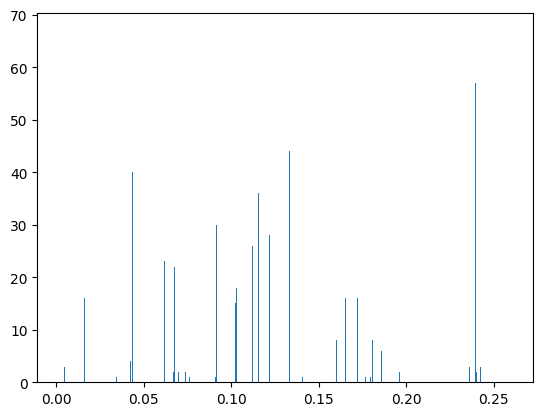

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

photonData = np.array(pd.read_csv("photonHits256.csv")) #need to upload this before running it each time but it will give same result
photonData = photonData[:,0]

plt.hist(photonData, bins=10000)
plt.show()

A the data for a single photon looks like the following.

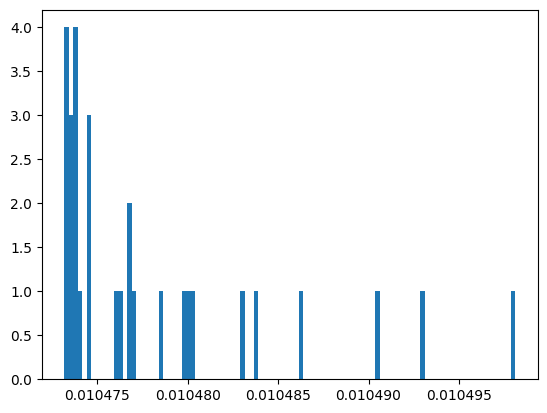

In [ ]:
cutPhotonData = []
for i in range(0, int(photonData.size/2)):
  if photonData[i] < 0.0105 and photonData[i] > 0.01:
    cutPhotonData.append(photonData[i])

plt.hist(cutPhotonData, bins=100)
plt.show()

Note the first histogram is made up of 256 clusters which look like this. We will therefore use clustering algorithms for this problem.

# **MODELS**


**KMeans**

The KMeans model is pretty simple on the surface. You run the model for multiple values of k and make an elbow plot to see which k you should choose. On the slide with the elbow plot it says, "this may work". Well, what do you do in the case where the elbow plot doesn't work? The answer is you have to get creative. I will break down my code explaining why I had to do each thing I did and explaining my though process.

In [ ]:
#KMEANS MODEL
import numpy as np
import pandas as pd
import sklearn
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import concurrent.futures
import time
import sys

**Cost Function**

One of the first issues I ran into was that the standard variance formula for determining how well the K clusters were assigned was not working in the way I wanted. Observe the first histogram from the data set section does not have 256 data peaks corresponding to the 256 neutrons, it has much less. One property of the data is that it forms a sort of hierarchy of clusters. By this I mean, the smaller sub clusters cluster together to form their own clusters. If you examine the variance function, the variance improvement for the algorithm identifying these higher-level clusters is orders of magnitude more than the algorithm identifying the lower order clusters.

Therefore, it was necessary to create some sort of cost function which would heavily reduce my cost metric when the algorithm identified the lower order clusters. The way I achieved this was with a piecewise function. I looked at my data and observed the average spread of the cluster I wanted to identify. I then made an if condition to run a certain cost function if I was within this range and use another function if I was outside the range.  

There were two important properties I needed in whatever function I created. One was that the biggest decrease in cost happened when the clusters I wanted were identified. The second was that the change in cost of identifying the higher order clusters did not outweigh the change in cost from the lower order clusters. I achieved this by using variance within my expected cluster range and a logarithm outside my expected cluster range.

In [ ]:
#User defined cost function, did not use just variance
def costFunction(dataPoint, mean):
    val = 0
    distance = np.absolute(dataPoint-mean)
    #Use variance as cost if we are within the expected distance
    if(distance < 0.0005):
        val = (dataPoint-mean) * (dataPoint-mean)
    #If we are outside the expected distance use a logarithm multiplied by a scalar
    else:
        val = 500* np.log(1+distance) * 500 * np.log(1+distance)
    return val

**Total KMeans Cost**

The cost function above was for the cost of a single data point. But I needed a metric for determining how well using a certain k was for a particular data set. Here this is no different from the typical KMeans algorithm of just running my cost function on each data point and their assigned cluster. Then summing all those up to get the total cost.

In [ ]:
#Returns cost across all assigned k cluster centers and their assigned data points. This is really the metric for how well the kmeans algorithm went.
def findVariance(dataLabelPair, clusterCenters, photonNum):
    totalVariance = 0   #Total variance
    subVariance = 0     #Counter for the subvariance which counts for the variance of one particualr cluster
    n = 0               #Counting the number of data points in a cluster so it can divide properly
    neutronIndex = 0    #Counting which cluster we are on (a cluster basically represents a neutron, as we would assume all the photons in a cluster came from one neutron)

    #loop through all data points
    for i in range (0, photonNum-1):
        #If the next neutron index equals this photon index, just continue calculating variance as usual
        #The photon index is the index saying which cluster it was assigned to
        if(dataLabelPair[i, 1] == dataLabelPair[i+1, 1]):
            subVariance = subVariance + costFunction(dataLabelPair[i, 0], clusterCenters[neutronIndex])
            n = n + 1
        #If the next neutron index does not equal the photon index, we know we have reached the end of all the data points assigned to a particular cluster
        else:
            if(n != 0): #if n was == 0 our program would crash
                subVariance = subVariance + costFunction(dataLabelPair[i, 0], clusterCenters[neutronIndex])
                subVariance = subVariance / n #like in the standard deviation formula, we divide by n
                totalVariance = totalVariance + subVariance
                subVariance = 0 #reseting these data points for itterating through the next set of cluster points
                n=0 #reseting these data points for itterating through the next set of cluster points
            neutronIndex = neutronIndex + 1 #setting our index identifiying which cluster we are on to the next cluster

    #case for factoring in the last data point. I would have gotten an out of bounds error if I had incremented 1 more in my loop. Therefore, I need this.
    if(dataLabelPair[photonNum-2, 1] == dataLabelPair[photonNum-1, 1]):
        subVariance = subVariance + costFunction(dataLabelPair[photonNum-1, 0], clusterCenters[neutronIndex])
        subVariance = subVariance / n
        totalVariance = totalVariance + subVariance

    return totalVariance

**Finding the correct K**

Creating an algorithm to find the correct K was the most difficult part of this project. This is the thing that will directly determine how good the algorithm is.

The runKMeansModel function is simple. You give it the data and a k to try, and it gives you the total cost from the function above.

The way I find performance of a particular k is the following. performance = totalCost_k-1 / totalCost_k. So just the total cost of the last k divided by the total cost of the current k you are getting performance for. The reason division was used instead of subtraction was twofold. One was that the order of magnitude of the total costs across all the k I tried was vast (like 10^6 different). Division gives a fairer metric for going from a total cost of 5* 10^6 -> 4.3* 10^6 as compared to only 5 -> 4.3. The next reason was, I could determine when the algorithm crossed the threshold of the correct k by observing when performance stayed consistent around one (cost no longer decreased from increasing k).

The next question is, what successive Ks should I use. To determine this, we must go back and consider our data set. Consider I will be getting from the user some 1D data set in which I do not know the number of neutrons. Also, the number of neutrons can have a very wide range, like 100 or 10000. Therefore, our correct K could range from 100-10000. We cannot just iterate from 100 to 10000 in k because that would also take an unacceptably long time. Also, it would be exceedingly difficult to distinguish the correct K down to a resolution of one.

Therefore, the routine is the following. Based on the range of neutrons the user expects, I slowly zero in on the correct K. This is best seen by example. Let's say the user gave me a range of 100 neutrons to 10000 neutrons. I start by having my successive Ks be a value of 1000 apart. My Ks I would use would be, {100, 1100, 2100, ..., 10100}. I then look at the performance for each one of those Ks (remember how I defined performance). I identify the K such that its performance is around one and chose the K two iterations back from that to be my next lower range. Let's look at an example as to why. Let's say I found K=2100 to have performance 8.4, K = 3100 to have performance 23.4 and K = 4100 to have performance 1.0435. The last time I see good performance is going from 2100 to 3100. Therefore, I know my correct K must be within that range. I can then have the next range of Ks be {2100, 2200, 2300, ..., 3100}. I then do the exact same thing until I zero into a resolution I am happy with.  

I can now explain my findCorrectKLowCount and findCorrectKHighCount functions. I have two separate functions for performing the operation described above depending on if the data is low count or high count. This is because their performance metrics need to be treated differently. With the 256-neutron data, a performance change from 255 to 256 might be detectable. With 5000 neutron data a performance change from 4999 to 5000 is not detectable. The only real difference between the functions is, to be able to detect higher resolutions for the low count data, I have one slight alteration. When determining the performance close to one, I average the next N performances (I call the stagnant index) and compare with that number with 1 instead of just performance. This helps smooth out performance behavior which tends to bounce around when the correct k value is exceeded. Otherwise, both functions work with the scheme above.

The last component is the cutoff parameter. This is a hyper-parameter which determines what performance I determine is "close to one". This is the most important hyper parameter in the program. I have different hyper parameters for the different ranges. These could theoretically be found by their own machine learning model, but the training would take way too long. They have been set by me by just observing what works.

In [ ]:
#Will actually preform the fitting of the data with a KMeans model
def runKMeansModel(numClusters, photonData, photonNum):
    clustering = KMeans(n_clusters=numClusters, n_init=50) #Create the kMeans model
    clustering.fit(photonData) #Let KMeans fit the data

    dataLabelPair = np.vstack((photonData[:, 0], clustering.labels_)).T #Get the cluster index assigned to each data point and pair that with the data point
    dataLabelPair = dataLabelPair[np.argsort(dataLabelPair[:, 1])] #Store the data so it is in order of assigned cluster

    variance = findVariance(dataLabelPair, clustering.cluster_centers_[:, 0], photonNum) #Use my user defiend metric to see how well the model did
    returnTupple = [variance, numClusters] #Pair the number of clusters used with the performance gotten when using that number of clusters
    return returnTupple

#Determine correct K for the low count data
def findCorrectKLowCount(performances, numPerformances, stagnantIndex, cutOffParameter):
    #stagnent index is how many performances will we include in our average to see if the performance metric has gone stanant
    avg = 0
    metric = np.empty([(numPerformances-stagnantIndex), 2]) #Metric is the averaged performances
    #calculate all the metrics
    for i in range(0, numPerformances-stagnantIndex):
        for j in range(0, stagnantIndex):
            avg = avg + performances[i+j, 0]
        avg = avg / stagnantIndex
        metric[i] = [avg, performances[i, 1]]
        avg = 0

    #return the k before the k such that its metric is less than the cut of parameter
    for i in range(0, numPerformances-stagnantIndex):
        if metric[i, 0] < cutOffParameter:
            return metric[i-1, 1]

    return 0

#Determine correct K for the high count data
def findCorrectKHighCount(performances, numPerformances, neutronScanStep, cutOffParameter):
    #return the k before the k such that its metric is less than the cut of parameter
    for i in range(0, numPerformances):
        if performances[i, 0] < cutOffParameter:
            if(i != 0):
                return performances[i-1, 1] - neutronScanStep
            else:
                return performances[i]

if __name__ == '__main__':
    t1 = time.time()
    #PROGRAM CONSTANTS
    recursiveNeutronStepConst = [1000, 250, 100, 25, 5]
    recursiveItterations = [10, 10, 10, 10, 15, 15]
    maxRecursiveSteps = len(recursiveNeutronStepConst)
    lowRangeItterations = 20
    highRangeItterations = 10
    topItterations = 10
    stagnantIndex = 5
    #In low, mid, high
    lowCountRangeParameter = [1.01, 3, 4]
    midCountRangeParameter = [1.03, 1.05, 1.5]
    highCountRangeParameter = [1.02, 1.05, 1.2]
    #Low range 0 to 1500, mid range 1500 to 5000, high range 5000 to 10000
    lowRangeEnd = 4
    midRangeEnd = 2
    highRangeEnd = 1

    #PROGRAM INPUT OPTIONS
    inputFileName = "photonHits256.csv"
    neutronLowRange = 150
    neutronHighRange = 500
    neutronRange = neutronHighRange - neutronLowRange
    correctNumNeutrons = inputFileName[10:]
    correctNumNeutrons = int(correctNumNeutrons[:-4])

    #Calculating program run variables
    startNeutronStepIndex = 0
    for i in range(0, maxRecursiveSteps):
        if (neutronRange / recursiveNeutronStepConst[i]) > 5:
            startNeutronStep = i
            break
    if neutronRange < 1500:
        countRangeParameter = lowCountRangeParameter
        rangeEnd = lowRangeEnd
    elif neutronHighRange >= 1500 and neutronHighRange <= 5000:
        countRangeParameter = midCountRangeParameter
        rangeEnd = midRangeEnd
    else:
        countRangeParameter = highCountRangeParameter
        rangeEnd = highRangeEnd

    #Get the data
    photonData = np.array(pd.read_csv(inputFileName))
    photonData[:, 1] = 0
    photonNum = int(photonData.size/2)

    firstItteration = 1 #boolean, I always want my first itteration over k to have 10 itterations so this marks if I am in my first itteration
    #Loop over neutron step counts to find the correct k
    for stepIndex in range(startNeutronStep, rangeEnd+1):
        #Creating an array of k's we will loop over for that particular step count
        itterations = 0
        neutronList = []
        if stepIndex != 4:
            for j in range(0, highRangeItterations):
                neutronList.append(neutronLowRange + (j * recursiveNeutronStepConst[stepIndex]))
            itterations = recursiveItterations[stepIndex]
        else:
            for j in range(0, lowRangeItterations):
                neutronList.append(neutronLowRange + (j * recursiveNeutronStepConst[stepIndex]))
            itterations = recursiveItterations[stepIndex]

        #Code for first itteration
        if firstItteration == 1:
            itterations = 10
            firstItteration = 0

        #Run the KMeans model for each k within my itteration
        variances = []
        for i in range(0, itterations):
            variances.append(runKMeansModel(neutronList[i], photonData, photonNum))

        #Sorting data to be in order so I can do computation (I do multiprocessing on my computer I tested this on so I had to sort the data. just going to keep it here)
        variances = np.array(variances)
        sortedIndexes = np.argsort(variances[:,1])
        sortedVariances = []
        for i in range(0, itterations):
            sortedVariances.append(variances[sortedIndexes[i]])
        sortedVariances = np.array(sortedVariances)

        #Calculate the performances
        performance = np.empty([(itterations-1), 2])
        for i in range(0, itterations-1):
            performance[i] = [(sortedVariances[i, 0] / sortedVariances[i+1, 0]), sortedVariances[i+1, 1]]

        #Cube the performances to make it easier to distinguish a near one value from a non near one value
        performanceThree = np.power(performance[:, 0], 3)
        performanceCubed = np.empty([(itterations-1), 2])
        for i in range(0, itterations-1):
            performanceCubed[i] = [performanceThree[i], performance[i, 1]]
        print("PERFORMANCE")
        print(performanceCubed)

        #Within the performance data find the k which is correct and set that to the neutron low range for next itteration
        if stepIndex == 0 or stepIndex == 1 or stepIndex == 2:
            neutronLowRange = int(findCorrectKHighCount(performanceCubed, itterations-1, recursiveNeutronStepConst[stepIndex], countRangeParameter[2]))
        elif stepIndex == 3:
            neutronLowRange = int(findCorrectKHighCount(performanceCubed, itterations-1, recursiveNeutronStepConst[stepIndex], countRangeParameter[1]))
        else:
            neutronLowRange = int(findCorrectKLowCount(performanceCubed, itterations-1, stagnantIndex, countRangeParameter[0]))

    #find accuracy for the algorithm
    predictedNeutrons = neutronLowRange + int(recursiveNeutronStepConst[rangeEnd]/2)
    accuracy = 1 - (abs(correctNumNeutrons - predictedNeutrons) / correctNumNeutrons)

    outputString = "Correct neutron number: " + str(correctNumNeutrons) + " Predicted neutron number: " + str(predictedNeutrons) + " Accuracy: " + str(accuracy) + "\n"
    print(outputString)

    t2 = time.time()
    print("Time: ", t2-t1)

PERFORMANCE
[[3.28863218e+14 1.75000000e+02]
 [1.72506532e+01 2.00000000e+02]
 [5.18791782e+01 2.25000000e+02]
 [1.82618141e+01 2.50000000e+02]
 [1.06230315e+00 2.75000000e+02]
 [1.04112454e+00 3.00000000e+02]
 [8.90677756e-01 3.25000000e+02]
 [1.01467562e+00 3.50000000e+02]
 [1.16007030e+00 3.75000000e+02]]
PERFORMANCE
[[  2.18965013 230.        ]
 [  2.04714733 235.        ]
 [  1.81840737 240.        ]
 [  1.89603813 245.        ]
 [  1.12820429 250.        ]
 [  1.0853491  255.        ]
 [  0.90884885 260.        ]
 [  1.09311877 265.        ]
 [  0.74813647 270.        ]
 [  1.18933541 275.        ]
 [  1.06461434 280.        ]
 [  1.02018674 285.        ]
 [  1.03212923 290.        ]
 [  0.68204152 295.        ]]
Correct neutron number: 256 Predicted neutron number: 247 Accuracy: 0.96484375

265.07044863700867


The algorithm is very computationally intensive. For any high neutron data, running the algorithm on a cluster would be the only option for reasonable execution time. It would be recommended to use other models.

**Density Estimation**


In [ ]:
#Density Estimation
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.signal import argrelextrema
from sklearn.neighbors import KernelDensity
from scipy.ndimage.filters import gaussian_filter
import time

t1 = time.time()

correct_hits = 256  #change this to the correct number of hits so we can calculate the score

# Read the excel file
data = pd.read_csv(f"photonHits{correct_hits}.csv")
data = data.loc[:, ~data.columns.str.contains('^Unnamed')]
# Convert the DataFrame to a NumPy array
timestamps = np.array(data)

#print(data)
print(timestamps)

# Standardize the data
scaler = StandardScaler()
scaled_timestamps = scaler.fit_transform(timestamps.reshape(-1, 1))

# Train a Kernel Density Estimation model with adjustable bandwidth
kde_optimized = KernelDensity(bandwidth=0.00001) #bandwith is so low to count the number of individual neutrons, not groups of neutrons
kde_optimized.fit(scaled_timestamps)

# Estimate the log density at each point to determine how dense the data point are around each timestamp
log_density_optimized = kde_optimized.score_samples(scaled_timestamps)

# Apply Gaussian filter to smooth the log-density estimation to reduce noise and make it easier to identify the local maxima
smoothed_log_density = gaussian_filter(log_density_optimized, sigma=3.34)

# Define a threshold for the log-density value to filter out maxima with low density. Uses the default value
threshold = 0.1

# Find local maxima in the smoothed log-density, above the threshold
local_maxima = argrelextrema(smoothed_log_density, np.greater_equal, order=1) #order=1 determines how many data points on each side to use to consider a point as a maxima

# Filter out maxima below the threshold
filtered_maxima = local_maxima[0][smoothed_log_density[local_maxima] >= threshold]

# Get the remaining number of clusters and print score
n_clusters_kde_optimized = len(filtered_maxima)
print(f"Number of clusters detected by optimized Kernel Density Estimation: {n_clusters_kde_optimized}")
score = 1 - (abs(correct_hits - n_clusters_kde_optimized) / correct_hits)
print(f"Score: {score}")

t2 = time.time()
print("Time: ", t2-t1)


<ipython-input-18-ed868ea799ce>:7: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


[[0.00195723]
 [0.00195728]
 [0.00195733]
 ...
 [0.25987575]
 [0.25988001]
 [0.25989044]]
Number of clusters detected by optimized Kernel Density Estimation: 257
Score: 0.99609375
Time:  0.5644285678863525


The Density Estimation Model was significantly simpler than the KMeans model. In the Density Estimation code, the data was fit as normal, then has a gaussian filter and a threshold value applied to the result. The fitting was run with a very low value of 0.00001 to determine where the individual neutron hits were located, instead of where clusters of neutron hits occurred. After this was done, the gaussian filter, with a sigma value of 3.34, and threshold was applied to reduce the noise and focus on the neutron hits. The performance evalutation used was a simple accuracy equation: $$Score = 1 - abs(CorrectHits-predictedHits) / CorrectHits$$

# **Performance Evaluation**

KMeans Performance

| Correct Neutron Count | Predicted Neutron Count | Accuracy |
| -------- | -------- | -------- |
| 256  | 262  | 97.65%  |
| 509  | 497  | 97.64%  |
| 1041  | 1002  | 96.25%  |
| 2465  | 2300  | 93.31%  |

Density Estimation Performance

| Correct Neutron Count | Predicted Neutron Count | Accuracy |
| -------- | -------- | -------- |
| 256  | 257  | 99.61%  |
| 509  | 515  | 98.82%  |
| 1041  | 1023  | 98.27%  |
| 2465  | 2363  | 95.86%  |

After running each model, we have determined that Density Estimation is significantly better. Although both models provide good results, Density Estimation resulted in better scores across the board.

The biggest point of interest is not the accuracy of each model, but the run time. Although KMeans does provide good accuracy, the runtime for this model is not usable. For the data used in the tables above, the model took upwards of three hours on 16 cores to run, and would only increase as the neutron counts increased. Density Estimation, however, took significantly less time, only taking about 2 minutes on one core for a neutron count of 2465. Naturally, the runtime increases more with larger datasets, taking up to around 20 minutes for a dataset of more than 5000 neutron hits on one core, but Kmeans would take up to 12 or more hours on 16 cores to model the same data and still result in worse accuracy. For this reason, we have decided to leave out the comparisons of the models with data containing more than 2500 neutron hits, as the runtime for Kmeans would simply take too long. In this report, we have used the 256-neutron hit dataset to report on the results and performances as this is the simplest dataset.

One other comparison to make between the two models is the complexity of each algorithm. To fit the problem at hand, Kmeans required a lot of user complexity to provide good results. To find the number of neutrons and not find locations of groups of neutrons, a unique cost function was created to heavily penalize clusters that were too big. This allows KMeans to find a neutron hit rather than places where there were a lot of neutrons hitting at the same time. The user also needed create an algorithm to find the optimal K, as trying to iterate through 10,000 K values would take multiple weeks to complete. Density Estimation on the other hand was very simple. It only required the usual normalization, and an additional gaussian filter and threshold to reduce the noise. The "noise" in this case would be the tail end of photon emissions from a single neutron hit; removing this would make the dense photon emission areas (and thus a neutron hit) more accurate. Although the math behind the Density Estimation is a little complex, the actual implementation was not.
